# PandaX-4T ER & NR yield models vs PRD Fig. 17

Monte-Carlo comparison of the diamx P4-NEST yield models (ER and NR) against Fig. 17 of the PandaX-4T signal-response paper (Phys. Rev. D **110**, 023029). Events from a uniform energy spectrum are run through the appletree components `ERYieldPandaX4T` / `NRYieldPandaX4T`, and the per-event `num_photon` / `num_electron` / `recomb_std` are histogrammed in energy to give the mean light yield, charge yield and recombination fluctuation $\Delta r$.

For each recoil the **standard-Legendre correction coefficients are refit** to the digitized Run0 LY+QY (the correction only repartitions charge$\leftrightarrow$light, so at fixed $\xi_{norm}$ the yields are linear in $p_0..p_3$ -> linear least squares), and the per-run shift $d$ is refit to Run1.

**Key model choices (see closing notes):** ER mean yields come from the NESTv2.0 *source* (Appendix A1 has misprints); NR from Eq. A2. $\Delta r$ uses the PRD skew-Gaussian/Gaussian in the quenched electron fraction $\zeta=N_e/(N_e+N_{ph})$. Both recoils use $\xi_{norm}=150$ keV (the paper's NR=30 entry is a typo). Drift fields: Run0 ~93, Run1 ~84 V/cm. **ER is shown first.**

In [1]:
import os
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import diamx
import appletree as apt
from diamx.appletree.plugins import p4_nest as P
from diamx.appletree.components.er_pandax4t import ERYieldPandaX4T
from diamx.appletree.components.nr_pandax4t import NRYieldPandaX4T
from diamx.appletree.get_file_path import get_file_path_diamx

XI_NORM = 150.0
FIELD_RUN0, FIELD_RUN1 = 93.0, 84.0
ddir = os.path.join(os.path.dirname(diamx.__file__), 'data')
def load(name):
    f = os.path.join(ddir, name)
    return np.loadtxt(f, delimiter=',') if os.path.exists(f) else None

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform


/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using aptext package from https://github.com/XENONnT/applefiles


## Shared helpers
`mc_yields` bins a component's per-event output in energy. `refit_p` does the linear least-squares refit of $p_0..p_3$ against the Run0 LY+QY (with a small ridge toward the Table II prior -- see below); `fit_d` refits the scalar Run1 shift $d$. Both use the deterministic baseline from the recoil's `*YieldParamsP4NEST` plugin (analytic and MC agree to <1% above ~5 keV).

**Why the ridge:** over a narrow energy range the four Legendre modes are nearly collinear (ER spans only $\xi/150<0.17$, where $L_0\approx1,L_2\approx-0.5$ are both ~constant and $L_1,L_3$ are both ~$\propto u$), so an unregularized fit is ill-conditioned and returns huge, non-unique coefficients. A small ridge toward the published Table II values resolves this; for NR (wide range) it is negligible.

In [2]:
def legendre(u, n):
    return [np.ones_like(u), u, (3 * u**2 - 1) / 2, (5 * u**3 - 3 * u) / 2][n]

def baseline(yield_plugin, params, Eg):
    """Deterministic baseline (no correction): Nq, Ni, <r>_0, and LY0/QY0."""
    _, lin, ionf, r0, _ = yield_plugin('x').simulate(
        jax.random.PRNGKey(0), params, jnp.asarray(Eg))
    lin = np.asarray(lin); ionf = np.asarray(ionf); r0 = np.asarray(r0)
    Nq = (Eg / params['w']) * lin; Ni = Nq * ionf
    LY0 = (Nq - Ni * (1 - r0)) / Eg; QY0 = (Ni * (1 - r0)) / Eg
    return Nq, Ni, r0, LY0, QY0

def _design(E, Ni, Eg, xinorm):
    NioE = np.interp(E, Eg, Ni) / E
    b = np.array([legendre(E / xinorm, n) * np.exp(-E / xinorm) for n in range(4)]).T
    return NioE[:, None] * b

def refit_p(yield_plugin, run0_params, ly_d, qy_d, xinorm, lo, hi, prior, ridge=0.05):
    Eg = np.linspace(1, hi + 5, 600)
    Nq, Ni, r0, LY0g, QY0g = baseline(yield_plugin, run0_params, Eg)
    def rows(d, base_g, sign):
        m = (d[:, 0] >= lo) & (d[:, 0] <= hi); E, y = d[m, 0], d[m, 1]
        A = sign * _design(E, Ni, Eg, xinorm)
        rhs = y - np.interp(E, Eg, base_g)
        return A / y[:, None], rhs / y
    A1, r1 = rows(ly_d, LY0g, +1.0); A2, r2 = rows(qy_d, QY0g, -1.0)
    A = np.vstack([A1, A2]); rhs = np.concatenate([r1, r2])
    # Ridge toward the published Table II prior. The four Legendre modes are
    # nearly collinear over a narrow energy range (ER: xi/150 < 0.17), so an
    # unregularized fit is ill-conditioned (huge, non-unique coefficients). The
    # ridge resolves this; for NR (wide range, well conditioned) it is negligible.
    prior = np.asarray(prior)
    A = np.vstack([A, np.sqrt(ridge) * np.eye(4)])
    rhs = np.concatenate([rhs, np.sqrt(ridge) * prior])
    p, *_ = np.linalg.lstsq(A, rhs, rcond=None)
    return p

def fit_d(yield_plugin, run1_params, p, ly_d, qy_d, xinorm, lo, hi):
    """Refit the scalar Run1 shift d (linear: d shifts <r> by a constant)."""
    Eg = np.linspace(1, hi + 5, 600)
    Nq, Ni, r0, _, _ = baseline(yield_plugin, run1_params, Eg)
    corr = sum(p[n] * legendre(Eg / xinorm, n) for n in range(4)) * np.exp(-Eg / xinorm)
    r_nod = np.clip(r0 + corr, 0, 1)              # Run1 <r> with d=0
    LY_nod = (Nq - Ni * (1 - r_nod)) / Eg; QY_nod = (Ni * (1 - r_nod)) / Eg
    def rows(d, base_g, sign):
        m = (d[:, 0] >= lo) & (d[:, 0] <= hi); E, y = d[m, 0], d[m, 1]
        col = sign * (np.interp(E, Eg, Ni) / E)   # d(yield)/d(d) = -/+ Ni/E
        rhs = y - np.interp(E, Eg, base_g)
        return (col / y)[:, None], rhs / y
    A1, r1 = rows(ly_d, LY_nod, +1.0); A2, r2 = rows(qy_d, QY_nod, -1.0)
    d, *_ = np.linalg.lstsq(np.vstack([A1, A2]), np.concatenate([r1, r2]), rcond=None)
    return float(d[0])

def mc_yields(comp, params, lo, hi, n=4_000_000, nbins=None):
    nbins = nbins or int(round((hi - lo)))
    key = apt.get_key(); key, out = comp.simulate(key, n, params)
    e, nph, ne, rs = (np.asarray(x) for x in out)
    edges = np.linspace(lo, hi, nbins + 1); ctr = 0.5 * (edges[:-1] + edges[1:])
    idx = np.digitize(e, edges) - 1
    ly = np.full(nbins, np.nan); qy = np.full(nbins, np.nan); dr = np.full(nbins, np.nan)
    for b in range(nbins):
        m = idx == b
        if m.sum() > 80:
            ly[b] = np.mean(nph[m] / e[m]); qy[b] = np.mean(ne[m] / e[m]); dr[b] = np.mean(rs[m])
    return ctr, ly, qy, dr

In [3]:
# per-recoil configuration
RECOILS = {
    'ER': dict(comp_cls=ERYieldPandaX4T, yp=P.ERYieldParamsP4NEST, prefix='er',
               par='pandax4t_er_par.json', lo=1.0, hi=25.0, fitlo=1.5, fithi=24.0,
               table2=[1.1, -3.1, 2.2, -1.7], xi_cfg='xi_norm_er',
               ymax=(60, 70, 0.10)),
    'NR': dict(comp_cls=NRYieldPandaX4T, yp=P.NRYieldParamsP4NEST, prefix='nr',
               par='pandax4t_nr_par.json', lo=1.0, hi=90.0, fitlo=2.0, fithi=90.0,
               table2=[0.7, -1.6, 1.3, -0.6], xi_cfg='xi_norm_nr',
               ymax=(16, 10, 0.12)),
}

def analyze(recoil):
    cfg = RECOILS[recoil]
    base = apt.Parameter(get_file_path_diamx(cfg['par'])); base.sample_prior()
    base = base.get_all_parameter()
    obs = recoil.lower()
    dig = {k: {r: load(f'pandax4t_{r}_{obs}_{k}.csv') for r in ['run0', 'run1']}
           for k in ['ly', 'qy', 'recomb_std']}
    pre = cfg['prefix']

    # refit Legendre coefficients on Run0, then the Run1 shift d
    run0 = dict(base, field=FIELD_RUN0, **{f'd_{pre}': 0.0})
    p = refit_p(cfg['yp'], run0, dig['ly']['run0'], dig['qy']['run0'],
                XI_NORM, cfg['fitlo'], cfg['fithi'], prior=cfg['table2'])
    run1 = dict(base, field=FIELD_RUN1, **{f'p{i}_{pre}': p[i] for i in range(4)})
    d1 = fit_d(cfg['yp'], run1, p, dig['ly']['run1'], dig['qy']['run1'],
               XI_NORM, cfg['fitlo'], cfg['fithi'])
    print(f'[{recoil}] refit p0..p3 = {np.round(p, 3)}   (Table II {cfg["table2"]})')
    print(f'[{recoil}] refit Run1 d = {d1:+.3f}')

    # build the MC component (xi_norm via config default = 150)
    comp = cfg['comp_cls'](recoil.lower())
    comp.set_config({'lower_energy': cfg['lo'], 'upper_energy': cfg['hi'] + 5})
    comp.deduce(data_names=['energy', 'num_photon', 'num_electron', 'recomb_std'],
                force_no_eff=True)
    comp.compile()

    pfit = {f'p{i}_{pre}': p[i] for i in range(4)}
    off = {f'p{i}_{pre}': 0.0 for i in range(4)}
    off.update({f'a_{pre}': 1.0, f'd_{pre}': 0.0})
    cases = {
        'NEST Run0':    dict(base, field=FIELD_RUN0, **off),
        'NEST Run1':    dict(base, field=FIELD_RUN1, **off),
        'P4-NEST Run0': dict(base, field=FIELD_RUN0, **pfit, **{f'd_{pre}': 0.0}),
        'P4-NEST Run1': dict(base, field=FIELD_RUN1, **pfit, **{f'd_{pre}': d1}),
    }
    res = {nm: mc_yields(comp, pr, cfg['lo'], cfg['hi']) for nm, pr in cases.items()}

    # plot
    style = {'NEST Run0': 'k--', 'NEST Run1': 'r--', 'P4-NEST Run0': 'b-', 'P4-NEST Run1': 'r-'}
    dcol = {'run0': 'tab:gray', 'run1': 'tab:orange'}
    fig, ax = plt.subplots(3, 1, figsize=(6, 10), sharex=True)
    for nm, (ctr, ly, qy, dr) in res.items():
        ax[0].plot(ctr, ly, style[nm], label=nm)
        ax[1].plot(ctr, qy, style[nm]); ax[2].plot(ctr, dr, style[nm])
    for j, k in enumerate(['ly', 'qy', 'recomb_std']):
        for r in ['run0', 'run1']:
            d = dig[k][r]
            if d is not None:
                ax[j].plot(d[:, 0], d[:, 1], 'o', ms=2.5, color=dcol[r],
                           label=(f'Fig.17 {r}' if j == 0 else None))
    ax[0].set_ylabel(r'$N_{ph}/\xi$ [photon/keV]'); ax[0].set_ylim(0, cfg['ymax'][0]); ax[0].legend(fontsize=8)
    ax[1].set_ylabel(r'$N_e/\xi$ [e/keV]'); ax[1].set_ylim(0, cfg['ymax'][1])
    ax[2].set_ylabel(r'$\Delta r$ (recomb_std)'); ax[2].set_ylim(0, cfg['ymax'][2])
    ax[2].set_xlabel('energy [keV]'); ax[2].set_xlim(0, cfg['hi'])
    fig.suptitle(f'diamx P4-NEST {recoil} yields by MC (vs PRD Fig. 17)')
    fig.tight_layout(); plt.show()

    # residual summary (P4-NEST vs digitized)
    def rez(nm, idx, k, r):
        d = dig[k][r]
        if d is None: return None
        ctr, mcy = res[nm][0], res[nm][idx]
        m = (d[:, 0] >= cfg['fitlo']) & (d[:, 0] <= cfg['fithi'])
        rel = (np.interp(d[m, 0], ctr, mcy) - d[m, 1]) / d[m, 1] * 100
        return np.nanmean(rel), np.nanmax(np.abs(rel))
    print(f"{'curve':14s}{'LY mean/max%':>15}{'QY mean/max%':>15}{'dr mean/max%':>15}")
    for nm in ['P4-NEST Run0', 'P4-NEST Run1']:
        r = 'run0' if 'Run0' in nm else 'run1'
        out = nm.ljust(14)
        for k, idx in [('ly', 1), ('qy', 2), ('recomb_std', 3)]:
            v = rez(nm, idx, k, r)
            out += (f'{v[0]:+5.1f}/{v[1]:4.1f}' if v else '    -   ').rjust(15)
        print(out)
    return p, d1

## Electronic recoils (ER)

[ER] refit p0..p3 = [ 1.189 -3.035  2.321 -1.738]   (Table II [1.1, -3.1, 2.2, -1.7])
[ER] refit Run1 d = -0.028


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


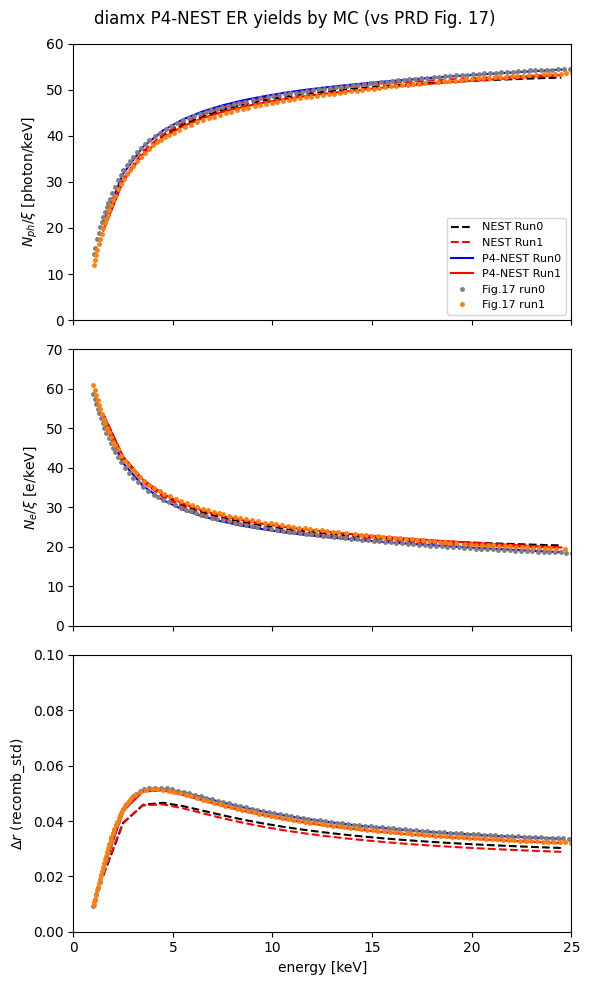

curve            LY mean/max%   QY mean/max%   dr mean/max%
P4-NEST Run0        -0.6/ 6.4      +0.1/ 4.1      -1.3/ 8.8
P4-NEST Run1        -0.4/ 5.3      +0.3/ 3.4      -1.6/ 8.0


In [4]:
p_er, d_er = analyze('ER')

## Nuclear recoils (NR)

[NR] refit p0..p3 = [ 0.725 -1.576  1.297 -0.629]   (Table II [0.7, -1.6, 1.3, -0.6])
[NR] refit Run1 d = -0.031


/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


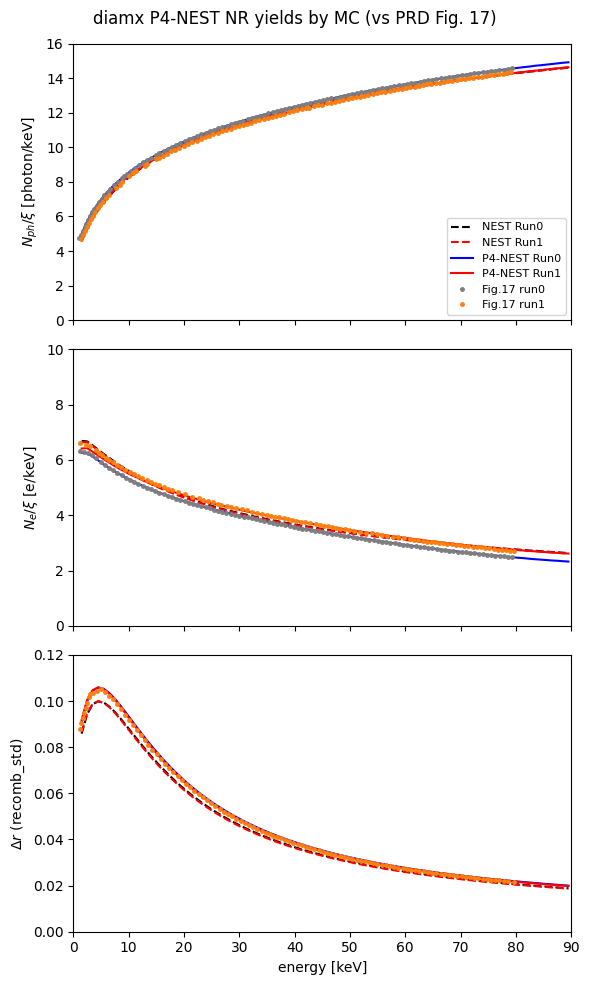

curve            LY mean/max%   QY mean/max%   dr mean/max%
P4-NEST Run0        -0.1/ 0.5      -0.0/ 0.6           -   
P4-NEST Run1        +0.2/ 2.5      -0.2/ 2.3      +0.5/ 1.5


In [5]:
p_nr, d_nr = analyze('NR')

## Findings
- **MC, not analytic:** every curve is the binned mean of events simulated by the appletree component (uniform spectrum -> P4-NEST plugins).
- **ER mean yields from the NESTv2.0 source** (NEST.cpp @ v2.0.0), not PRD App. A1, which has misprints (its Qy is ~2x too high at 25 keV). NR yields from Eq. A2.
- **$\xi_{norm}=150$ keV for both recoils.** Eq. 17 lists 30 for NR, but 30 makes the degree-3 Legendre term overshoot (NR: $\langle r\rangle\to0$ by ~50 keV; ER: LY/QY reverse by ~20 keV). The NR=30 entry is a typo -- it is NOT an ER$\leftrightarrow$NR swap (the ER curves need 150 too).
- **$\Delta r$ uses the quenched electron fraction** $\zeta=N_e/(N_e+N_{ph})$ (reproduces the Fig. 17 scale); the literal Eq. A1/A2 $N_eW/(1000\xi)$ is ~10x too small and looks like a misprint.
- **Legendre coefficients refit** to the digitized Run0 LY+QY for each recoil (linear LS, ridge toward Table II); the per-run shift $d$ refit to Run1. NR refits cleanly to ~Table II. The **ER refit is degenerate** over its narrow range (the unregularized fit gives huge non-unique coefficients); with the ridge it confirms the published Table II ER coefficients to ~1%. Both runs prefer $d\approx-0.03$ (close to the paper's d_ER, not d_NR=-0.043).